In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

master_df = pd.read_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\master_dataset.csv"
)

master_df["Month"] = pd.to_datetime(master_df["Month"])

master_df.head()

,Month,Occupation,Demand,SOC_Code,Median_Salary
0,2023-01-01,Programmers and software development professio...,25269.0,2134.0,52500
1,2023-02-01,Programmers and software development professio...,25118.0,2134.0,55000
2,2023-03-01,Programmers and software development professio...,21905.0,2134.0,55000
3,2023-04-01,Programmers and software development professio...,15409.0,2134.0,55000
4,2023-05-01,Programmers and software development professio...,17787.0,2134.0,55000


In [2]:
X = master_df[["Demand"]]
y = master_df["Median_Salary"]

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", r2_score(y, predictions))

Slope: 0.6595783513845399
Intercept: 44493.67619070192
R²: 0.10259002031881381


In [3]:
regression_results = pd.DataFrame({
    "Slope":[model.coef_[0]],
    "Intercept":[model.intercept_],
    "R2":[r2_score(y,predictions)]
})

regression_results.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\regression_results.csv",
    index=False
)

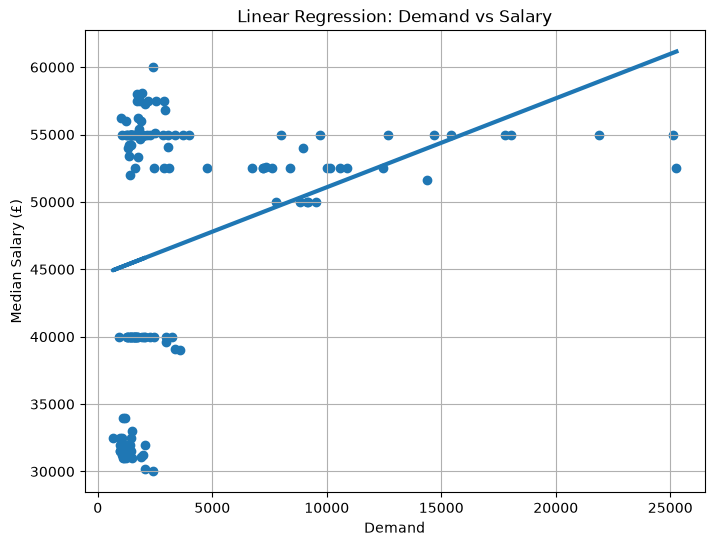

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(master_df["Demand"],
            master_df["Median_Salary"])

plt.plot(master_df["Demand"],
         predictions,
         linewidth=3)

plt.xlabel("Demand")

plt.ylabel("Median Salary (£)")

plt.title("Linear Regression: Demand vs Salary")

plt.grid(True)

plt.show()

In [5]:
plt.savefig(
    r"D:\MScProjects\labour-market-intelligence\results\regression_plot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [6]:
growth = (
    master_df
    .groupby("Occupation")
    .apply(
        lambda x: (
            x["Demand"].iloc[-1]-x["Demand"].iloc[0]
        )/x["Demand"].iloc[0]*100
    )
)

growth

Occupation
Actuaries, economists and statisticians               -36.188330
Cyber security professionals                          -34.886853
Data analysts                                         -44.370494
Database administrators and web content technicians   -41.218189
Programmers and software development professionals    -49.784321
dtype: float64

In [7]:
growth.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\demand_growth.csv"
)

In [8]:
salary_rank = (
    master_df
    .groupby("Occupation")["Median_Salary"]
    .mean()
    .sort_values(ascending=False)
)

salary_rank

Occupation
Cyber security professionals                           55662.068966
Actuaries, economists and statisticians                54731.034483
Programmers and software development professionals     52868.965517
Data analysts                                          39920.689655
Database administrators and web content technicians    31717.241379
Name: Median_Salary, dtype: float64

In [9]:
salary_rank.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\salary_ranking.csv"
)

In [10]:
demand_rank = (
    master_df
    .groupby("Occupation")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

demand_rank

Occupation
Programmers and software development professionals     11714.068966
Actuaries, economists and statisticians                 1988.379310
Cyber security professionals                            1924.827586
Data analysts                                           1903.413793
Database administrators and web content technicians     1317.137931
Name: Demand, dtype: float64

In [11]:
demand_rank.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\demand_ranking.csv"
)

In [2]:
import pandas as pd
from pathlib import Path

project_path = Path(
    r"D:\MScProjects\labour-market-intelligence"
)

processed_path = project_path / "data" / "processed"

# Load validated monthly demand
monthly_demand = pd.read_csv(
    processed_path / "digital_monthly_demand_2023_2025.csv"
)

# Load salary dataset
salary = pd.read_csv(
    processed_path / "salary_2023_2025.csv"
)

print("MONTHLY DEMAND")
print("Shape:", monthly_demand.shape)
print("Columns:")
print(monthly_demand.columns.tolist())

print("\nFirst 5 rows:")
print(monthly_demand.head())

print("\n" + "=" * 70)

print("SALARY DATA")
print("Shape:", salary.shape)
print("Columns:")
print(salary.columns.tolist())

print("\nFirst 10 rows:")
print(salary.head(10))

print("\nData types:")
print(salary.dtypes)

MONTHLY DEMAND
Shape: (108, 6)
Columns:
['Month', 'Year', 'SOC_Code', 'Occupation', 'Skill_Category', 'Job_Adverts']

First 5 rows:
        Month  Year  SOC_Code  \
0  2023-01-01  2023      2134   
1  2023-02-01  2023      2134   
2  2023-03-01  2023      2134   
3  2023-04-01  2023      2134   
4  2023-05-01  2023      2134   

                                          Occupation        Skill_Category  \
0  Programmers and software development professio...  Software Development   
1  Programmers and software development professio...  Software Development   
2  Programmers and software development professio...  Software Development   
3  Programmers and software development professio...  Software Development   
4  Programmers and software development professio...  Software Development   

   Job_Adverts  
0      25269.0  
1      25118.0  
2      21905.0  
3      15409.0  
4      17787.0  

SALARY DATA
Shape: (145, 4)
Columns:
['SOC_Code', 'Occupation', 'Month', 'Median_Salary']

First 

In [3]:
# Load validated annual demand + ONS ASHE salary dataset
validated_annual = pd.read_csv(
    processed_path / "integrated_digital_demand_salary_2023_2025.csv"
)

print("Shape:", validated_annual.shape)

print("\nColumns:")
print(validated_annual.columns.tolist())

print("\nDataset:")
print(validated_annual.to_string(index=False))

print("\nMissing values:")
print(validated_annual.isna().sum())

Shape: (9, 10)

Columns:
['Year', 'SOC_Code', 'Occupation', 'Skill_Category', 'Observed_Months', 'Total_Job_Adverts', 'Average_Monthly_Adverts', 'YoY_Demand_Growth_Pct', 'Median_Annual_Salary', 'Salary_Growth_Pct']

Dataset:
 Year  SOC_Code                                         Occupation       Skill_Category  Observed_Months  Total_Job_Adverts  Average_Monthly_Adverts  YoY_Demand_Growth_Pct  Median_Annual_Salary  Salary_Growth_Pct
 2023      2134 Programmers and software development professionals Software Development               12           194205.0                  16183.8                    NaN                 49444                NaN
 2024      2134 Programmers and software development professionals Software Development               12            98969.0                   8247.4                 -49.04                 53363               7.93
 2025      2134 Programmers and software development professionals Software Development               12           113816.0             

In [4]:
# ============================================================
# Correlation analysis: demand and salary
# Unit of analysis = occupation-year
# ============================================================

from scipy.stats import pearsonr, spearmanr

analysis_df = validated_annual[
    [
        "Year",
        "SOC_Code",
        "Occupation",
        "Skill_Category",
        "Average_Monthly_Adverts",
        "Median_Annual_Salary"
    ]
].copy()

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    analysis_df["Average_Monthly_Adverts"],
    analysis_df["Median_Annual_Salary"]
)

# Spearman rank correlation
spearman_r, spearman_p = spearmanr(
    analysis_df["Average_Monthly_Adverts"],
    analysis_df["Median_Annual_Salary"]
)

print("Number of occupation-year observations:", len(analysis_df))

print("\nPearson correlation")
print(f"r = {pearson_r:.3f}")
print(f"p-value = {pearson_p:.4f}")

print("\nSpearman correlation")
print(f"rho = {spearman_r:.3f}")
print(f"p-value = {spearman_p:.4f}")

print("\nAnalysis dataset:")
print(analysis_df.to_string(index=False))

Number of occupation-year observations: 9

Pearson correlation
r = 0.472
p-value = 0.1993

Spearman correlation
rho = 0.433
p-value = 0.2440

Analysis dataset:
 Year  SOC_Code                                         Occupation       Skill_Category  Average_Monthly_Adverts  Median_Annual_Salary
 2023      2134 Programmers and software development professionals Software Development                  16183.8                 49444
 2024      2134 Programmers and software development professionals Software Development                   8247.4                 53363
 2025      2134 Programmers and software development professionals Software Development                   9484.7                 55587
 2023      2135                       Cyber security professionals        Cybersecurity                   2457.8                 45573
 2024      2135                       Cyber security professionals        Cybersecurity                   1428.6                 48555
 2025      2135               

In [5]:
# ============================================================
# Exploratory OLS regression
# Salary ~ labour demand
# Unit of analysis = occupation-year
# ============================================================

import statsmodels.api as sm

reg_df = analysis_df[
    [
        "Average_Monthly_Adverts",
        "Median_Annual_Salary"
    ]
].dropna().copy()

X = reg_df[["Average_Monthly_Adverts"]]
X = sm.add_constant(X)

y = reg_df["Median_Annual_Salary"]

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Median_Annual_Salary   R-squared:                       0.223
Model:                              OLS   Adj. R-squared:                  0.112
Method:                   Least Squares   F-statistic:                     2.009
Date:                  Sat, 15 Aug 2026   Prob (F-statistic):              0.199
Time:                          18:49:59   Log-Likelihood:                -92.682
No. Observations:                     9   AIC:                             189.4
Df Residuals:                         7   BIC:                             189.8
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

In [7]:
import statsmodels.formula.api as smf

# Build regression dataset from the validated annual dataset
regression_df = validated_annual[
    [
        "Year",
        "SOC_Code",
        "Skill_Category",
        "Average_Monthly_Adverts",
        "Median_Annual_Salary"
    ]
].dropna().copy()

# Ensure appropriate data types
regression_df["SOC_Code"] = regression_df["SOC_Code"].astype(str)
regression_df["Year"] = regression_df["Year"].astype(str)

print("Regression dataset:")
print(regression_df.to_string(index=False))

print("\nNumber of observations:", len(regression_df))

# Model 2:
# Salary ~ Demand + Skill Category + Year
model_2 = smf.ols(
    formula=(
        "Median_Annual_Salary ~ "
        "Average_Monthly_Adverts + "
        "C(Skill_Category) + "
        "C(Year)"
    ),
    data=regression_df
).fit()

print("\nMODEL 2 RESULTS")
print(model_2.summary())

Regression dataset:
Year SOC_Code       Skill_Category  Average_Monthly_Adverts  Median_Annual_Salary
2023     2134 Software Development                  16183.8                 49444
2024     2134 Software Development                   8247.4                 53363
2025     2134 Software Development                   9484.7                 55587
2023     2135        Cybersecurity                   2457.8                 45573
2024     2135        Cybersecurity                   1428.6                 48555
2025     2135        Cybersecurity                   1846.0                 54816
2023     3544       Data Analytics                   2466.6                 33695
2024     3544       Data Analytics                   1459.7                 34125
2025     3544       Data Analytics                   1656.4                 38107

Number of observations: 9

MODEL 2 RESULTS
                             OLS Regression Results                             
Dep. Variable:     Median_Annual_Sa

In [8]:
# ============================================================
# Save regression results for dissertation / dashboard evidence
# ============================================================

regression_results = pd.DataFrame({
    "Model": [
        "Model 1: Demand only",
        "Model 2: Demand + Skill Category + Year"
    ],
    "N": [
        int(model.nobs),
        int(model_2.nobs)
    ],
    "R_Squared": [
        model.rsquared,
        model_2.rsquared
    ],
    "Adjusted_R_Squared": [
        model.rsquared_adj,
        model_2.rsquared_adj
    ],
    "Demand_Coefficient": [
        model.params["Average_Monthly_Adverts"],
        model_2.params["Average_Monthly_Adverts"]
    ],
    "Demand_P_Value": [
        model.pvalues["Average_Monthly_Adverts"],
        model_2.pvalues["Average_Monthly_Adverts"]
    ],
    "Model_F_P_Value": [
        model.f_pvalue,
        model_2.f_pvalue
    ]
})

regression_results = regression_results.round(4)

output_path = processed_path / "regression_results_final.csv"
regression_results.to_csv(output_path, index=False)

print(regression_results.to_string(index=False))
print("\nSaved:", output_path)

                                  Model  N  R_Squared  Adjusted_R_Squared  Demand_Coefficient  Demand_P_Value  Model_F_P_Value
                   Model 1: Demand only  9     0.2230              0.1120              0.7869          0.1993           0.1993
Model 2: Demand + Skill Category + Year  9     0.9858              0.9622             -0.1518          0.7212           0.0057

Saved: D:\MScProjects\labour-market-intelligence\data\processed\regression_results_final.csv
